# Определение наилучшей дислокации единственного подразделения (BLP)

Первой и простейшей задачей размещения подразделений пожарной охраны является Задача определения наилучшей дислокации единственного подразделения (далее – **BLP**, от англ. *Best Location Problem*).

В общем виде процесс решения задачи размещения можно представить следующим образом:

```{mermaid}
flowchart LR
  classDef style_optional  stroke-dasharray: 5 5
  classDef style_main  stroke:green, color:green

  load_data("**ЗАГРУЗКА
  ИСХОДНЫХ
  ДАННЫХ**"):::style_main

  data["Исходные
  данные"]
  settings["Настройки"]

  action("**ПРИМЕНЕНИЕ
  АЛГОРИТМА**"):::style_main

  model("**ИНИЦИАЛИЗАЦИЯ
  АЛГОРИТМА**"):::style_main

  result["Результат"]

  analyze("**АНАЛИЗ**"):::style_main
  save("**СОХРАНЕНИЕ**"):::style_main

  is_ok{"Результат
  приемлем"}

  fix("Изменение подхода"):::style_optional


  load_data --> data --> action
  model --> action
  settings --> model

  action --> result
  result --> analyze
  result -.-> save

  analyze --> is_ok

  is_ok -- ДА --> save
  is_ok -. НЕТ .-> fix

```

Поиск наилучшей дислокации начинается с загрузки требуемых исходных данных и настройки алгоритма решения задачи размещения, затем алгоритм с использованием переданных данных решает задачу размещения, результаты анализируются и сохраняются для последующего использования или анализа средствами QGIS. Также решение о сохранении результатов может быть принято после их анализа и оценки приемлемости. Если полученные результаты по тем или иным причинам не приемлемы, расчет может быть повторен с измененными настройками, исходными данными или иным алгоритмом решения задачи BLP.

В **Генезис** реализованы следующие алгоритмы решения задачи BLP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` Алгоритм жадного добавления (ADD) - *рекомендуемый*,
- Прочие:
  - `genesis.best_points.BestNodesFull` Полный перебор
  - `genesis.best_points.BestNodeHillClimbing` Скалолаз (HC)
  - `genesis.best_points.BestNodeHillClimbing_maxMean` Скалолаз (HC), модификация для метрик максимальное время + среднее время
  - `genesis.best_points.BestNodeMonkey` Алгоритм обезьяньего поиска (MSA)
  - `genesis.best_points.BestNodeBee` Алгоритм искусственной пчелиной колонии (ABC)

В данном разделе рассмотрен только рекомендуемый алгоритм. Прочие решения рассматриваются в разделе **Для разработчиков**.

## Подключение требуемых библиотек

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.035


## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки при размещении пожарного депо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

Последовательность использования ADD для решения задачи  можно представить в следующем виде

```{mermaid}
flowchart LR
  classDef style_optional  stroke-dasharray: 5 5
  classDef style_main  stroke:green, color:green

  load_data("**ЗАГРУЗКА
  ИСХОДНЫХ
  ДАННЫХ**"):::style_main

  matrix("**МАТРИЦА ПРИБЫТИЯ**")

  model("**ИНИЦИАЛИЗАЦИЯ
  АЛГОРИТМА**"):::style_main

  action("**ПРИМЕНЕНИЕ
  АЛГОРИТМА**"):::style_main

  analyze("**АНАЛИЗ**"):::style_main
  save("**СОХРАНЕНИЕ**"):::style_main

  data["Исходные
  данные"]
  settings["Настройки"]
  


  settings --> matrix
  settings --> model
  model --> action
  load_data --> data --> action
  data --> matrix
  matrix --> model

  action --> analyze
  action --> save

```

## Загрузка исходных данных

In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Матрица прибытия

Матрица прибытия - таблица в которой строками являются идентификаторы узлов зданий, столбцами - идентификаторы узлов графа из которых можно попасть в каждое из зданий, в ячейках хранится числовое значение времени прибытия из каждого узла графа к каждому из зданий, либо значение `NaN`, означающее, что из узла $N_n$ нельзя попасть к зданию $B_n$, за заданное время (@tbl-atm-example-2).

|  | $N_1$ | $N_2$ | $N_3$ | $N_4$ | $N_5$ |
| - | ---- | ----- | ----- | --- | ----- |
| $B_1$ | 3,1 | 4,2 | 1,5 | 13,2 | 7,5 |
| $B_2$ | 6,6 | `NaN` | 14,2 | 7,2 | 3,3 |
| $B_3$ | 4,2 | 6,1 | `NaN` | 6,4 | 12,3 |
| $B_4$ | `NaN` | 12,9 | 4,5 | `NaN` | `NaN` |
| $B_5$ | 6,3 | `NaN` | `NaN` | `NaN` | 2,1 |
: Пример матрицы прибытия {#tbl-atm-example-2}

В приведенном примере (@tbl-atm-example-2) можно заметить, что узлом из которого можно попасть за 10 минут в наибольшее количество зданий является узел $N_1$ (4 здания) - этот узел и является предпочтительным для размещения пожарного депо.

Матрица рассчитывается при помощи функции `genesis.states.get_atm`:

In [3]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 2000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


## Сборка и инициализация алгоритма

Для решения задачи определения наилучшей дислокации единственного подразделения выбирается условие остановки при количестве создаваемых подразделений >= 1:

    stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1

In [11]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1      # Расчет проводится для 1 подразделения

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Применение алгоритма

### Расчет без учета имеющихся подразделений {.unnumbered}

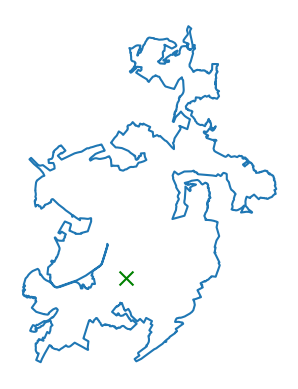

In [12]:
# 3. Расчет BLP (применение алгоритма)
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Анализ результатов
## Печать места размещения
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

### Расчет с учетом имеющихся подразделений {.unnumbered}

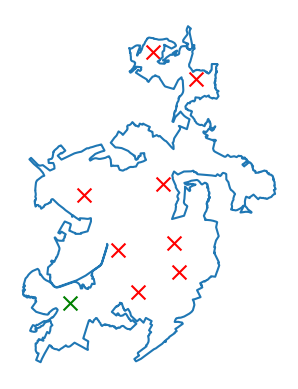

In [13]:
# 3. Расчет BLP (применение алгоритма)
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Анализ результатов
## Печать места размещения
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
g_nodes.loc[units_dict.keys()].plot(ax=ax, color='red', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

## Сохранение

In [7]:
# Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Сохранение новых подразделений
## Создание нового набора данных
new_units = pd.DataFrame(best_nodes.items(), columns=['node', 'name'])
## Сопоставление с узлами ГДС
new_units = g_nodes.merge(new_units, left_index=True, right_on='node')
## Оставляем только нужные столбцы [имя, координаты, геометрия]
new_units = new_units[['name', 'x', 'y', 'geometry']]
## Сохранение в файл 'new_units.gpkg' и слой 'результат BLP'
new_units.to_file('data/kemerovo/new_units.gpkg', driver='GPKG', layer='результат BLP')